In [4]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import pdb
import numpy as np
import plotly.graph_objects as go
import json
import re

def get_df_from_train_gen(file: str):
    raw_jl = open(file, 'r', encoding='utf-8').read()

    first_key = raw_jl.split('"')[1]
    json_list = [] 
    for i, raw_json in enumerate(re.split(r'{\s*"'+first_key+r'": \[\s*"', raw_jl.strip())):
        if raw_json.strip():
            json_list.append(json.loads('{"'+first_key+'": [ "' + raw_json))
    df = pd.DataFrame(json_list)
    return df

def get_df_from_train_gen(file: str):
    raw_jl = open(file, 'r', encoding='utf-8').read()

    json_list = []
    one_method_to_split = raw_jl.strip().split("\n}")
    end_str = "\n}"
    if len(one_method_to_split) == 1: # detect other mode of data generation.
        one_method_to_split = raw_jl.strip().split("\n")
        end_str = "\n"

    for i, raw_json in enumerate(one_method_to_split):
        if raw_json.strip():
            json_list.append(json.loads(raw_json + end_str))
    df = pd.DataFrame(json_list)
    return df


def deduplicate_df(dfraw):
    odf = pd.concat([pd.DataFrame(dfraw.iloc[i].to_dict()) for i in range(len(dfraw))]) # concatenate all the evaluated batches. some questions may be duplicated across batches
    odf['questions']=odf.apply(lambda x: x.full_trajectory_strings.split("user\n")[1].split("assistant\n")[0], axis=1) # extract questions 
    keep_uid_per_q = ( # one traj_uid per question (first seen)
        odf.groupby('questions')['traj_uid']
        .transform('first'))            # the chosen uid for that question
    odf_deduplicated = odf[odf['traj_uid'] == keep_uid_per_q]
    assert len(odf_deduplicated.groupby('traj_uid').size()) == len(odf_deduplicated.groupby('questions').size())
    return odf_deduplicated

EVAL_PATH = "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/"
def load_df(file, eval_folder_path = EVAL_PATH + "colabbench_grpo_"):
    dfraw = get_df_from_train_gen(eval_folder_path + file)
    return deduplicate_df(dfraw)


eval_folder_path = "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/colabbench_grpo_"

In [3]:
abbel_50_s3file = 'qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_SEED_3_inference_4/50/train_gen.txt'
abbel_bg_50_s3file ='qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_LOG_PROB_OBS_SEED_3_inference_4/50/train_gen.txt'
abbel_100_s3file ='qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_SEED_3_inference_4/100/train_gen.txt'
abbel_bg_100_s3file ='qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_LOG_PROB_OBS_SEED_3_inference_4/100/train_gen.txt'

abbel_50_df = load_df(abbel_50_s3file)
abbel_bg_50_df = load_df(abbel_bg_50_s3file)
abbel_100_df = load_df(abbel_100_s3file)
abbel_bg_100_df = load_df(abbel_bg_100_s3file)

In [4]:
# seed 1
abbel_100_df_s1 = load_df("qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_inference_4/100/train_gen.txt")
abbel_50_df_s1 = load_df("qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_2_inference_4/50/train_gen.txt")
abbel_bg_100_df_s1 = load_df("qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0GRPO_INSTRUCT_G_BG_RECONSTRUCT_OBS_inference_4/100/train_gen.txt")
abbel_bg_50_df_s1 = load_df("qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0GRPO_INSTRUCT_G_BG_RECONSTRUCT_OBS_inference_4/50/train_gen.txt")

In [7]:
vanilla_zero_df = load_df("qwen2.5-7b-instruct_16_seed1_sc_True_belief_promp_False_is_mem1_False_belief_lp_0VANILLA_inference_4/0/train_gen.txt")
vanilla_50_df = load_df("qwen2.5-7b-instruct_16_seed1_sc_True_belief_promp_False_is_mem1_False_belief_lp_0VANILLA_inference_4/50/train_gen.txt")
vanilla_100_df = load_df("qwen2.5-7b-instruct_16_seed1_sc_True_belief_promp_False_is_mem1_False_belief_lp_0VANILLA_inference_4/100/train_gen.txt")
abbel_zero_df = load_df("qwen2.5-7b-instruct_16_seed1_sc_False_belief_promp_True_is_mem1_False_belief_lp_0ABBEL_inference_4/0/train_gen.txt")

In [ ]:
vanilla_50_df_s3 = load_df(EVAL_PATH +"colabbench__ckpt_qwen2.5-7b-instruct_16_seed3_sc_True_belief_promp_False_is_mem1_False_belief_lp_0_bg_0.0_0GRPO_INSTRUCT_G_VANILLA_3/global_step_50_inference_4/train_gen.txt", eval_folder_path = "")
vanilla_100_df_s3 = load_df(EVAL_PATH +"colabbench__ckpt_qwen2.5-7b-instruct_16_seed3_sc_True_belief_promp_False_is_mem1_False_belief_lp_0_bg_0.0_0GRPO_INSTRUCT_G_VANILLA_3/global_step_100_inference_4/train_gen.txt", eval_folder_path = "")

In [ ]:
with open(eval_folder_path + "qwen2.5-7b-instruct_16_seed1_sc_True_belief_promp_False_is_mem1_False_belief_lp_0VANILLA_inference_4/0/train_gen.txt", "r", encoding="utf-8") as src:
    #src.seek(1000)            # jump to character index 1000
    chunk = src.read(1000)    # read next 1000 characters

with open("output.txt", "w", encoding="utf-8") as dst:
    dst.write(chunk)


first_key = chunk.split('"')[1]
re.split(r'{\s*"'+first_key+r'": \[\s*"', chunk)

['',
 '7bf6c88d-0a88-4cfb-81c0-c8955139cc92",\n    "171cbfb1-066d-4e71-8b77-6c2632b8ca3c",\n    "bdc0bd25-0bc3-43a3-966d-9652df327ef6",\n    "069f9149-eb10-42a5-b11b-3eba838dd496",\n    "0f384e47-a7b6-475d-96f2-5e9309d2d0ca",\n    "0f57d246-9cc3-43d1-8e09-92afb6f44ffe",\n    "0ea4682b-8057-4ff7-9d9c-b02fcf421d5a",\n    "7e65a780-c4ae-4511-833f-b04f99c39d9d",\n    "19e602c5-b237-44d2-a1b3-29782b0f4f21",\n    "6fbb7331-0302-4975-bb50-939ceafbf376",\n    "ebda2f41-16c8-4f11-ae20-99b30b3a9b59",\n    "08fb80c3-5ec0-4087-9342-14569d5b6e4d",\n    "b3dc46e9-6c1f-4050-902b-c39003b3ce0e",\n    "e661ae5d-756b-47ce-bd57-fd1574f37188",\n    "bfdfa4a0-1eba-46c4-b87a-38ff70efb168",\n    "7e303a00-1441-4a42-8e46-7f66a8c074db",\n    "688935f5-dfbe-4f67-a1c5-a60d43b261f9",\n    "2005d14c-29e4-462d-b957-53c0557086bd",\n    "3da37c4a-a3ae-490d-863c-af63ef183862",\n    "00a510aa-ce2c-43e4-8281-5b61b93bb2a6",\n    "6bc4cacc-5f15-4814-9238-ab00676763ee",\n    "aee46a7e-19eb-4388-bb09-3d16c2f74d5a",\n    "0bd

In [92]:
len(abbel_zero_df.groupby('traj_uid'))

1024

In [97]:
len(vanilla_zero_df.groupby('traj_uid'))

1024

In [8]:
# instantiate tokenizer
from verl.utils import hf_tokenizer
from verl.utils.fs import copy_to_local

MODEL_PATH='qwen/qwen2.5-7b-instruct'
local_path = copy_to_local(MODEL_PATH, use_shm=False)
tokenizer = hf_tokenizer(local_path, trust_remote_code=False, is_instruct_model=True)

In [9]:
import re

def extract_tag_text(text, tag):
    """Extract first instance of text between <tag></tag> tags"""
    if f"<{tag}>" in text and f"</{tag}>" in text:
        pattern = f'<{tag}>(.*?)</{tag}>'
        matches = re.findall(pattern, text, re.DOTALL)
        tagtext = matches[0].strip()
        subtracted_text = text.replace(f"<{tag}>{tagtext}</{tag}>", "")
    elif f"<{tag}>" in text and (tag in ["information", "environment"]) and (text[-len("\nassistant\n"):] == "\nassistant\n"): # search results got cut off and it goes straight to assistant
        print(f"missing </{tag}>")
        tagtext = text.split(f"<{tag}>",1)[1][:-len("\nassistant\n")] 
        subtracted_text = text.replace(f"<{tag}>{tagtext}","")
    elif (f"<{tag}>" not in text) or (f"</{tag}>" not in text) and (tag == 'think') and '<search>' in text: # malformed internal state for MEM1
        print(f"missing opening and/or closing think tags")
        tagtext = text.split(f"<search>",1)[0] #MEM1 treats everything before <search> as the internal state
        subtracted_text = text.replace(tagtext, "")
    else:
        import pdb; pdb.set_trace()
        return "", text
    
    return tagtext, subtracted_text

def compute_peak_token_vanilla(traj_df, tokenizer) -> float:
    if traj_df.episode_rewards.max() == 0:
        return None
    full_traj_string = traj_df.full_trajectory_strings.iloc[0]
    output_str = full_traj_string.split('\nassistant\n', 1)[1] # remove initial instructions/system prompt as done in Zhou et al. MEM1 evals
    return len(tokenizer.encode(output_str))


def compute_peak_token_ABBEL(traj_df, tokenizer,memory_only=False) -> float:
    if traj_df.episode_rewards.max() == 0:
        return None
    peak_count = 0
    for i,row in traj_df.iterrows():
        if row.step == 0:
            input_str, input_belief = "", ""
        else:
            input_str = row.input_ids_str.split('</query>\n', 1)[1] # remove initial instructions/system prompt ending in the user query as done in Zhou et al. MEM1 evals
            input_belief, input_str_extracted = extract_tag_text(input_str, 'belief')
            if row['info']['action_or_belief'] == 1: # belief update step
                input_action, input_str_extracted = extract_tag_text(input_str_extracted, 'action')
                input_observation, _ = extract_tag_text(input_str_extracted, 'environment')
                if len(input_observation) == 0:
                    import pdb; pdb.set_trace()
                input_str = input_belief + input_action + input_observation
            else:
                input_str = input_belief  
        output_str = row.response_ids_str
        #import ipdb; ipdb.set_trace()
        if memory_only:
            peak_count = max(peak_count, len(tokenizer.encode(input_belief)))
        else:
            peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))

    if peak_count == 0:
        return None

    return peak_count

def compute_peak_token_MEM1(traj_df, tokenizer,memory_only=False) -> float:
    if traj_df.episode_rewards.max() == 0:
        return None
    peak_count = 0
    for i,row in traj_df.iterrows():
        if row.step == 0:
            input_str, input_IS = "", ""
        else:
            input_str = row.input_ids_str.split('\n\nassistant\n', 1)[1] # remove initial instructions/system prompt as done in Zhou et al. MEM1evals
            input_IS, input_str_extracted = extract_tag_text(input_str, 'think') # previous internal state
            input_action, input_str_extracted = extract_tag_text(input_str_extracted, 'action')
            input_observation, _ = extract_tag_text(input_str_extracted, 'information')
            if len(input_observation) == 0:
                import pdb; pdb.set_trace()
            input_str = input_IS + input_action + input_observation
        output_str = row.response_ids_str
        if memory_only:
            peak_count = max(peak_count, len(tokenizer.encode(input_IS)))
        else:
            peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))

    if peak_count == 0:
        return None
    return peak_count

def compute_peak_token_all_trajectories(df, framework, tokenizer, memory_only=False) -> float:
# Create a dictionary of dataframes, one for each unique traj_uid
    all_peak_tokens = []
    for traj_uid, traj_df in df.groupby('traj_uid'):
        if framework == 'vanilla':
            all_peak_tokens.append(compute_peak_token_vanilla(traj_df, tokenizer))
        else:
            traj_df = traj_df.reset_index(drop=True).sort_values(by='step')
            if framework == 'ABBEL':
                all_peak_tokens.append(compute_peak_token_ABBEL(traj_df, tokenizer, memory_only))
            elif framework == 'MEM1':
                all_peak_tokens.append(compute_peak_token_MEM1(traj_df, tokenizer, memory_only))
        
      # filter out None
    all_peak_tokens = [x for x in all_peak_tokens if x is not None]
    return all_peak_tokens

def compute_scores(df):
    return df.groupby('traj_uid').episode_rewards.max()

def compute_successes(df):
    return df.groupby('traj_uid').episode_rewards.max()==1.0

def get_all_metrics(df, framework, tokenizer, memory_only=False):
    tokens = compute_peak_token_all_trajectories(df, framework, tokenizer)
    scores = compute_scores(df)
    successes = compute_successes(df)
    return tokens, scores, successes

In [198]:
(abbel_df.groupby('traj_uid').episode_rewards.max()==1.0).mean()

np.float64(0.31640625)

In [116]:
abbel_bg_100_df.groupby('traj_uid').episode_rewards.max().mean(), np.mean(abbel_bg_100_df.groupby('traj_uid').episode_rewards.max())

(np.float64(0.45820312533760443), np.float64(0.45820312533760443))

In [ ]:
abbel_zero_metrics = get_all_metrics(abbel_zero_df, 'ABBEL', tokenizer)
abbel_50_metrics = get_all_metrics(abbel_50_df, 'ABBEL', tokenizer)
abbel_bg_50_metrics = get_all_metrics(abbel_bg_50_df, 'ABBEL', tokenizer)
abbel_100_metrics = get_all_metrics(abbel_100_df, 'ABBEL', tokenizer)
abbel_bg_100_metrics = get_all_metrics(abbel_bg_100_df, 'ABBEL', tokenizer)

In [67]:
abbel_50_metrics_s1 = get_all_metrics(abbel_50_df_s1, 'ABBEL', tokenizer)
abbel_bg_50_metrics_s1 = get_all_metrics(abbel_bg_50_df_s1, 'ABBEL', tokenizer)
abbel_100_metrics_s1 = get_all_metrics(abbel_100_df_s1, 'ABBEL', tokenizer)
abbel_bg_100_metrics_s1 = get_all_metrics(abbel_bg_100_df_s1, 'ABBEL', tokenizer)

In [10]:
vanilla_zero_metrics = get_all_metrics(vanilla_zero_df, 'vanilla', tokenizer)
vanilla_50_metrics = get_all_metrics(vanilla_50_df, 'vanilla', tokenizer)
vanilla_100_metrics = get_all_metrics(vanilla_100_df, 'vanilla', tokenizer)
vanilla_50_metrics_s3 = get_all_metrics(vanilla_50_df_s3, 'vanilla', tokenizer)
vanilla_100_metrics_s3 = get_all_metrics(vanilla_100_df_s3, 'vanilla', tokenizer)


In [313]:
# step 100
abg_belieflens = compute_peak_token_all_trajectories(abbel_bg_df, 'ABBEL', tokenizer, memory_only=True)
a_belieflens = compute_peak_token_all_trajectories(abbel_df, 'ABBEL', tokenizer, memory_only=True)
np.mean(abg_belieflens), np.std(abg_belieflens)/np.sqrt(len(abg_belieflens)), np.mean(a_belieflens), np.std(a_belieflens)/np.sqrt(len(a_belieflens))

(np.float64(140.05685618729098),
 np.float64(1.9047006753331617),
 np.float64(116.24137931034483),
 np.float64(1.7949591896959312))

In [11]:
def print_stats(tokens, scores, successes, error='SEM'):
    """scores, successes,tokens * 10^2"""
    if error == 'SEM':
        error_fun = lambda x: np.std(x)/np.sqrt(len(x))
    elif error == 'SD':
        error_fun = lambda x: np.std(x)
    round_to = 4
    stat_str = ""
    stat_str += '& ' + str(round(np.mean(np.array(scores)), round_to))+'$\pm $' + str(round(error_fun(scores), round_to))
    stat_str += " "
    stat_str += '& ' + str(round(np.mean(successes), round_to))+'$\pm $' + str(round(error_fun(successes), round_to))
    stat_str += " "
    stat_str += '& ' + str(round(np.mean(np.array(tokens)*0.01), round_to))+'$\pm $' + str(round(error_fun(np.array(tokens)*0.01), round_to))
    return stat_str + ' \\\\'

In [ ]:
for seed_pairs in [(abbel_50_metrics, abbel_50_metrics_s1), (abbel_bg_50_metrics, abbel_bg_50_metrics_s1), (abbel_100_metrics, abbel_100_metrics_s1), (abbel_bg_100_metrics, abbel_bg_100_metrics_s1)]:
    seed_means = []
    for metrics_tuple in seed_pairs:
        seed_means.append([np.mean(metric) for metric in metrics_tuple])
    seed_means = np.array(seed_means).T
    print(print_stats(seed_means[0], seed_means[1], seed_means[2], error='SEM'))


& 0.3844$\pm $0.014 & 0.2651$\pm $0.0093 & 3.4078$\pm $0.0499 \\
& 0.456$\pm $0.0132 & 0.3228$\pm $0.0079 & 3.9693$\pm $0.2542 \\
& 0.4655$\pm $0.0112 & 0.3286$\pm $0.0121 & 3.8614$\pm $0.0711 \\
& 0.4577$\pm $0.0004 & 0.3262$\pm $0.0021 & 3.4149$\pm $0.321 \\


In [12]:
for seed_pairs in [(vanilla_50_metrics, vanilla_50_metrics_s3), (vanilla_100_metrics, vanilla_100_metrics_s3)]:
    seed_means = []
    for metrics_tuple in seed_pairs:
        seed_means.append([np.mean(metric) for metric in metrics_tuple])
    seed_means = np.array(seed_means).T
    print(print_stats(seed_means[0], seed_means[1], seed_means[2], error='SEM'))

& 0.4364$\pm $0.0065 & 0.3066$\pm $0.0014 & 10.86$\pm $1.329 \\
& 0.5018$\pm $0.0171 & 0.3667$\pm $0.019 & 11.0753$\pm $2.2562 \\


In [14]:
print(0.3066+0.0014, 0.3228-0.0079)

0.308 0.31489999999999996


In [142]:
for metric_tuples in [vanilla_zero_metrics, abbel_zero_metrics, vanilla_50_metrics, vanilla_100_metrics]:
    print(print_stats(metric_tuples[0], metric_tuples[1], metric_tuples[2], error='SEM'))

& 0.2827$\pm $0.0125 & 0.1748$\pm $0.0119 & 4.5938$\pm $0.1532 \\
& 0.2642$\pm $0.0125 & 0.1709$\pm $0.0118 & 3.2953$\pm $0.0525 \\
& 0.4456$\pm $0.0139 & 0.3047$\pm $0.0144 & 8.9805$\pm $0.1396 \\
& 0.526$\pm $0.0141 & 0.3936$\pm $0.0153 & 7.8845$\pm $0.1084 \\


In [121]:
1-(0.526-0.465)/0.526

0.8840304182509506

In [146]:
# step 50
abg_belieflens_s1 = compute_peak_token_all_trajectories(abbel_bg_50_df_s1, 'ABBEL', tokenizer, memory_only=True)
a_belieflens_s1 = compute_peak_token_all_trajectories(abbel_50_df_s1, 'ABBEL', tokenizer, memory_only=True)
np.mean(abg_belieflens_s1), np.std(abg_belieflens_s1)/np.sqrt(len(abg_belieflens_s1)), np.mean(a_belieflens_s1), np.std(a_belieflens_s1)/np.sqrt(len(a_belieflens_s1))

(np.float64(149.36260162601627),
 np.float64(2.257671985520243),
 np.float64(103.47126436781609),
 np.float64(1.8874739878097175))

In [14]:
# step 100
def get_belieflens_and_tokens(df):
    belieflens = compute_peak_token_all_trajectories(df, 'ABBEL', tokenizer, memory_only=True)
    tokens = compute_peak_token_all_trajectories(df, 'ABBEL', tokenizer)
    return belieflens, tokens

abg_belieflens_s1, abg_tokens_s1 = get_belieflens_and_tokens(abbel_bg_100_df_s1)
print(np.mean(abg_tokens_s1)-np.mean(abg_belieflens_s1))
a_belieflens_s1, a_tokens_s1 = get_belieflens_and_tokens(abbel_100_df_s1)
print(np.mean(a_tokens_s1)-np.mean(a_belieflens_s1))

246.82636749691954
279.9618464961068


In [13]:
abg_belieflens_s2, abg_tokens_s2 = get_belieflens_and_tokens(abbel_bg_100_df)
print(np.mean(abg_tokens_s2)-np.mean(abg_belieflens_s2))
a_belieflens_s2, a_tokens_s2 = get_belieflens_and_tokens(abbel_100_df)
print(np.mean(a_tokens_s2)-np.mean(a_belieflens_s2))

209.2846231733348
262.2086092715232


In [12]:
abg_belieflens_s2, abg_tokens_s2 = get_belieflens_and_tokens(abbel_bg_50_df)
print(np.mean(abg_tokens_s2)-np.mean(abg_belieflens_s2))
a_belieflens_s2, a_tokens_s2 = get_belieflens_and_tokens(abbel_50_df)
print(np.mean(a_tokens_s2)-np.mean(a_belieflens_s2))

246.46979002914355
236.54007795723027


In [15]:
abg_belieflens_s2, abg_tokens_s2 = get_belieflens_and_tokens(abbel_bg_50_df_s1)
print(np.mean(abg_belieflens_s2), np.mean(abg_tokens_s2))
a_belieflens_s2, a_tokens_s2 = get_belieflens_and_tokens(abbel_50_df_s1)
print(np.mean(a_belieflens_s2), np.mean(a_tokens_s2))

149.36260162601627 432.87060702875397
103.47126436781609 333.72495446265935


In [143]:
# seed 2 
abg_belieflens_s2 = compute_peak_token_all_trajectories(abbel_bg_50_df, 'ABBEL', tokenizer, memory_only=True)
a_belieflens_s2 = compute_peak_token_all_trajectories(abbel_50_df, 'ABBEL', tokenizer, memory_only=True)

In [153]:
means_bg = [np.mean(abg_belieflens_s2),np.mean(abg_belieflens_s1)]
means_nobg = [np.mean(a_belieflens_s2),np.mean(a_belieflens_s1)]
print(np.mean(means_bg), np.std(means_bg)/np.sqrt(len(means_bg)))
print(np.mean(means_nobg), np.std(means_nobg)/np.sqrt(len(means_nobg)))

131.937799946457 12.321195428447094
107.3807261296283 2.764406922566916


In [150]:
np.mean(a_belieflens_s2), np.std(a_belieflens_s2)/np.sqrt(len(a_belieflens_s2)), np.mean(abg_belieflens_s2), np.std(abg_belieflens_s2)/np.sqrt(len(abg_belieflens_s2))

(np.float64(111.2901878914405),
 np.float64(2.0212053338594087),
 np.float64(114.51299826689775),
 np.float64(1.7599789079080932))

In [152]:
abbel_bg_50_df.groupby('traj_uid').episode_rewards.max().mean()
abbel_50_df.groupby('traj_uid').episode_rewards.max().mean()

np.float64(0.3646484380296897)

In [216]:
abbel_zero_df.groupby('traj_uid').step.max().mean(), vanilla_zero_df.groupby('traj_uid').episode_lengths.mean().mean()

(np.float64(12.640625), np.float64(2.81640625))

In [217]:
abbel_df.groupby('traj_uid').step.max().mean()

np.float64(17.8203125)

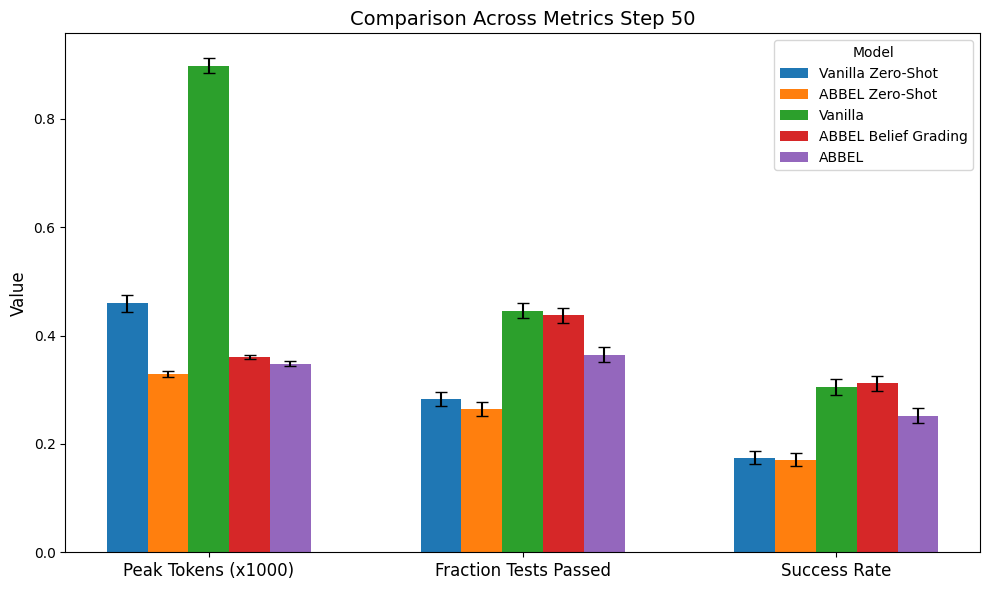

& 0.283$\pm $0.013 & 0.175$\pm $0.012 & 4.594$\pm $0.153 \\
& 0.264$\pm $0.013 & 0.171$\pm $0.012 & 3.295$\pm $0.053 \\
& 0.446$\pm $0.014 & 0.305$\pm $0.014 & 8.98$\pm $0.14 \\
& 0.437$\pm $0.014 & 0.312$\pm $0.014 & 3.61$\pm $0.038 \\
& 0.365$\pm $0.014 & 0.252$\pm $0.014 & 3.478$\pm $0.043 \\


In [101]:
def plot_bar_chart(tokens_list, scores_list, successes_list, model_names, title):
    # Compute means and standard errors
    tokens_means = [np.mean(np.array(toks)*0.001) for toks in tokens_list]
    tokens_sems = [np.std(np.array(toks)*0.001)/np.sqrt(len(toks)) for toks in tokens_list]
    scores_means = [np.mean(np.array(scores)) for scores in scores_list]
    scores_sems = [np.std( np.array(scores))/np.sqrt(len(scores)) for scores in scores_list]
    successes_means = [np.mean(succ) for succ in successes_list]
    successes_sems = [np.std(succ)/np.sqrt(len(succ)) for succ in successes_list]

    # Each metric will be an x-tick, models are the bars at each position
    metric_names = ['Peak Tokens (x1000)', 'Fraction Tests Passed', 'Success Rate']
    n_metrics = len(metric_names)
    n_models = len(model_names)
    means = [tokens_means, scores_means, successes_means]         # shape: (3 metrics, 5 models)
    sems = [tokens_sems, scores_sems, successes_sems]             # shape: (3 metrics, 5 models)

    x = np.arange(n_metrics)
    width = 0.13  # bar width; adjust if needed

    fig, ax = plt.subplots(figsize=(10,6))

    for i, (model, color) in enumerate(zip(model_names, plt.cm.tab10.colors)):
        model_means = [means[j][i] for j in range(n_metrics)]
        model_sems = [sems[j][i] for j in range(n_metrics)]
        ax.bar(x + (i - n_models/2 + 0.5)*width, model_means, width, yerr=model_sems, capsize=4, label=model, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(title='Model', fontsize=10)
    plt.tight_layout()
    plt.show()

    for tokens, scores, successes in zip(tokens_list, scores_list, successes_list):
        print(print_stats(tokens, scores, successes))

# Define model names and the corresponding data
model_names = ['Vanilla Zero-Shot', 'ABBEL Zero-Shot', 'Vanilla', 'ABBEL Belief Grading', 'ABBEL']
tokens_list = [vanilla_zero_metrics[0], abbel_zero_metrics[0], vanilla_50_metrics[0], abbel_bg_50_metrics[0], abbel_50_metrics[0]]
scores_list = [vanilla_zero_metrics[1], abbel_zero_metrics[1], vanilla_50_metrics[1], abbel_bg_50_metrics[1], abbel_50_metrics[1]]
successes_list = [vanilla_zero_metrics[2], abbel_zero_metrics[2], vanilla_50_metrics[2], abbel_bg_50_metrics[2], abbel_50_metrics[2]]

plot_bar_chart(tokens_list, scores_list, successes_list, model_names, 'Comparison Across Metrics Step 50')

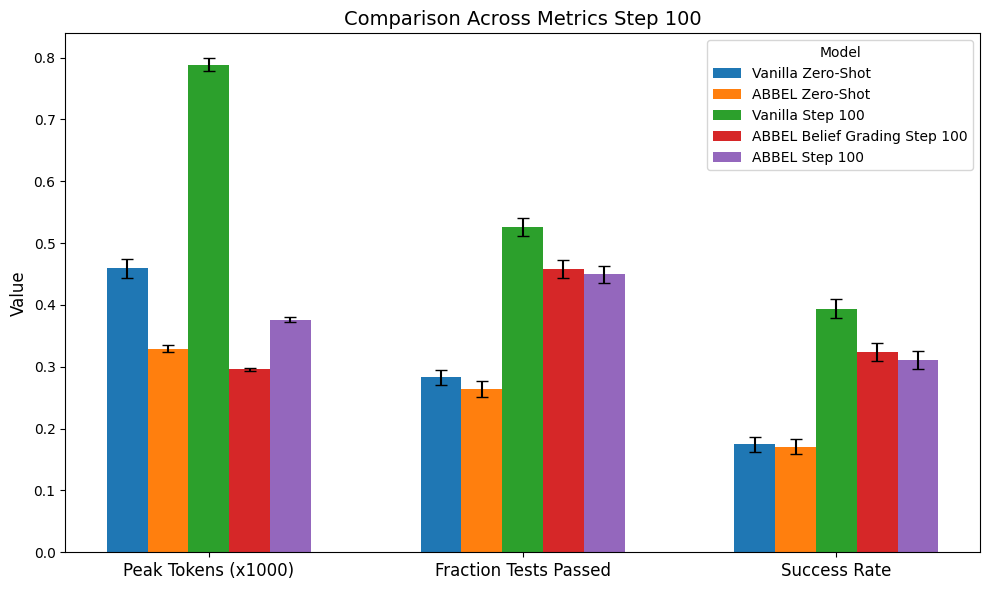

& 0.283$\pm $0.013 & 0.175$\pm $0.012 & 4.594$\pm $0.153 \\
& 0.264$\pm $0.013 & 0.171$\pm $0.012 & 3.295$\pm $0.053 \\
& 0.526$\pm $0.014 & 0.394$\pm $0.015 & 7.884$\pm $0.108 \\
& 0.458$\pm $0.014 & 0.323$\pm $0.015 & 2.961$\pm $0.026 \\
& 0.45$\pm $0.014 & 0.312$\pm $0.014 & 3.761$\pm $0.039 \\


In [104]:
# step 50:
# Define model names and the corresponding data
model_names = ['Vanilla Zero-Shot', 'ABBEL Zero-Shot', 'Vanilla Step 100', 'ABBEL Belief Grading Step 100',  'ABBEL Step 100']
tokens_list = [vanilla_zero_metrics[0], abbel_zero_metrics[0], vanilla_100_metrics[0], abbel_bg_100_metrics[0], abbel_100_metrics[0]]
scores_list = [vanilla_zero_metrics[1], abbel_zero_metrics[1], vanilla_100_metrics[1], abbel_bg_100_metrics[1], abbel_100_metrics[1]]
successes_list = [vanilla_zero_metrics[2], abbel_zero_metrics[2], vanilla_100_metrics[2], abbel_bg_100_metrics[2], abbel_100_metrics[2]]

plot_bar_chart(tokens_list, scores_list, successes_list, model_names, 'Comparison Across Metrics Step 100')


In [117]:
abbel_100_df_s1.groupby('traj_uid').episode_rewards.max().mean()

np.float64(0.4812500005355105)

In [104]:
count = 0
for i, traj_df in vanilla_df.groupby('traj_uid'):
    if traj_df.episode_rewards.iloc[0] > 0:
        break
print(traj_df.full_trajectory_strings.iloc[0])

system
You are a helpful LLM agent. 
Your task is to help a human user to resolve their problem, in particular python programming.
1) Note that the problem is highly personalized so you need to explicitly gather information 
by asking questions to the human user about some hidden information and implicit constraints.
YOU SHOULD TRY TO ASK CLARIFICATION QUESTIONS. Put your questions within <ask> ... </ask>.
2) Note that you should not ask human users complicated questions as they will only answer questions briefly in two sentences.
3) When you have gathered enough information to answer, put your final python code within <code> ... </code>.
4) Note that you can only interact with the human users WITHIN 10 back-and-forth rounds and you have to provide your final answer before the conversation ends.
5) You should be as concise as possible in your response to human.
6) Think step-by-step in think tags before you act. i.e <think> ... </think> <ask> ... </ask> or <think> ... </think> <code> .

In [338]:
count = 0
for i, traj_df in abbel_df.groupby('traj_uid'):
    if traj_df.episode_rewards.max() == 0:
        count += 1
        if count == 3:
            break
asks = re.findall(r'<belief>(.*?)</belief>', traj_df.full_trajectory_strings.iloc[0])
pprint(asks[::3])
print(traj_df.full_trajectory_strings.iloc[0])

['No prior belief.',
 'The current year is 2023, the target year is 2050, and the reduction '
 'percentage is 50%. The function will be called with these values to '
 'calculate the emissions cuts needed.',
 ' ... ',
 'The target year is 2050, the reduction percentage is 50%, and the current '
 'emissions data for the European Union, Canada, and Japan is missing.',
 'your new beliefs',
 'Target year: 2050, Reduction percentage: 50%, Current emissions data is '
 'missing.',
 'Target year: 2050, Reduction percentage: 50%, Current emissions data '
 'missing.',
 ' ... ',
 'Target year: 2050, Reduction percentage: 50%, Current emissions data '
 'missing.',
 'your new beliefs',
 'Target year: 2050, Reduction percentage: 50%, Current emissions data: '
 'missing, Need to clarify if function should be general or specific for '
 'certain data.',
 'Target year: 2050, Reduction percentage: 50%, Function should be general, '
 'Current emissions data: missing',
 ' ... ',
 'Target year: 2050, Reducti

In [ ]:
count = 0
for i, traj_df in abbel_bg_df.groupby('traj_uid'):
    break
    if traj_df.episode_rewards.max() > 0:
        break
asks = re.findall(r'<belief>(.*?)</belief>', traj_df.full_trajectory_strings.iloc[0])
print(asks[::3])

['No prior belief.', 'The user plans to calculate the break-even point and margin of safety for a specific year, where the inputs (revenue, fixed_costs, and variable_costs) are individual values. The function needs to work with single numbers for those three parameters for that year.', ' ... ', 'The user wants the function to calculate the break-even point (where net profit is zero) and the margin of safety (as the degree to which sales can drop before a loss) as a percentage of current sales. The function will be provided with individual values for revenue, fixed costs, and variable costs to perform these calculations for a specific year.', 'your new beliefs', 'The user wants the function to accept individual values as arguments, not a dictionary. The function should handle cases where the variable costs are close to or equal to the revenue. No specific edge cases are required for now, but handling the scenario when variable costs are close to or equal to the revenue is a good practic

: 

In [178]:
count = 0
for i, traj_df in abbel_df.groupby('traj_uid'):
    count += 1
    if count == 5:
        break
traj_df.sort_values(by='step', ascending=True, inplace=True)
for i, row in traj_df.iterrows():
    if '<ask>' in row.response_ids_str:
        question = row.response_ids_str.split('<ask>')[1].split('</ask>')[0]
        if 'belief' in question:
            print(question)
        #print(row.response_ids_str.split('<ask>')[1].split('</ask>')[0])

Is everything correct with the function's logic as described in the belief?


In [179]:
print(traj_df.full_trajectory_strings.iloc[0])

system
You are a helpful LLM agent. 
Your task is to help a human user to resolve their problem, in particular python programming.
1) Note that the problem is highly personalized so you need to explicitly gather information 
by asking questions to the human user about some hidden information and implicit constraints.
YOU SHOULD TRY TO ASK CLARIFICATION QUESTIONS. Put your questions within <ask> ... </ask>.
2) Note that you should not ask human users complicated questions as they will only answer questions briefly in two sentences.
3) When you have gathered enough information to answer, put your final python code within <code> ... </code>.
4) Note that you can only interact with the human users WITHIN 10 back-and-forth rounds and you have to provide your final answer before the conversation ends.
5) You should be as concise as possible in your response to human.
6) Think step-by-step in think tags before you act. i.e <think> ... </think> <ask> ... </ask> or <think> ... </think> <code> .

In [184]:
vanilla_df.success_rate.max()

np.float64(1.0)

In [239]:
count = 0
for i, traj_df in abbel_bg_df.groupby('traj_uid'):
    if traj_df.episode_rewards.max() == 0:
        count += 1
        if count == 1:
            break
print(traj_df.full_trajectory_strings.iloc[0])

system
You are a helpful LLM agent. 
Your task is to help a human user to resolve their problem, in particular python programming.
1) Note that the problem is highly personalized so you need to explicitly gather information 
by asking questions to the human user about some hidden information and implicit constraints.
YOU SHOULD TRY TO ASK CLARIFICATION QUESTIONS. Put your questions within <ask> ... </ask>.
2) Note that you should not ask human users complicated questions as they will only answer questions briefly in two sentences.
3) When you have gathered enough information to answer, put your final python code within <code> ... </code>.
4) Note that you can only interact with the human users WITHIN 10 back-and-forth rounds and you have to provide your final answer before the conversation ends.
5) You should be as concise as possible in your response to human.
6) Think step-by-step in think tags before you act. i.e <think> ... </think> <ask> ... </ask> or <think> ... </think> <code> .

In [158]:
print(traj_df['info'].iloc[0]['ground_truth'])

def calculate_mortgage_interest(principal, interest_rate, loan_term):
    monthly_interest_rate = interest_rate / 12 / 100
    number_of_payments = loan_term * 12
    monthly_payment = principal * monthly_interest_rate * (1 + monthly_interest_rate) ** number_of_payments / ((1 + monthly_interest_rate) ** number_of_payments - 1)
    total_interest = monthly_payment * number_of_payments - principal
    return total_interest


In [240]:
traj_df.sort_values(by='step', ascending=True, inplace=True)
for i, row in traj_df.iterrows():
    if '<ask>' in row.response_ids_str:
        print(row.response_ids_str.split('<ask>')[1].split('</ask>')[0])


Can you give me a list of the basic commands and numbers you want to recognize? For example, will 'forward' be mapped to a specific action, and what range of digits are we expecting to handle? 
Could you please specify the actions corresponding to each command and how we can send commands to the Android device running ICS without overlapping the current app window UI? 
Will the function distinguish between different speakers or is it only set up for a single user? If it's for multiple users, how will it differentiate their commands?
What method do you propose for sending commands to the Android device without overlapping the current app window? Are there any specific libraries or APIs that can be used for this purpose?
Does the voice command need to be in a specific language, or are you looking for a generic solution that recognizes words like 'forward' and 'backward' and digits? Have you considered using any specific libraries or APIs for interacting with Android devices?
Do you want 

In [169]:
count = 0
for i, atraj_df in vanilla_df.groupby('traj_uid'):
    if atraj_df.episode_rewards.iloc[0] == 0:
        count += 1
        if count == 3:
            break
print(atraj_df.full_trajectory_strings.iloc[0])

system
You are a helpful LLM agent. 
Your task is to help a human user to resolve their problem, in particular python programming.
1) Note that the problem is highly personalized so you need to explicitly gather information 
by asking questions to the human user about some hidden information and implicit constraints.
YOU SHOULD TRY TO ASK CLARIFICATION QUESTIONS. Put your questions within <ask> ... </ask>.
2) Note that you should not ask human users complicated questions as they will only answer questions briefly in two sentences.
3) When you have gathered enough information to answer, put your final python code within <code> ... </code>.
4) Note that you can only interact with the human users WITHIN 10 back-and-forth rounds and you have to provide your final answer before the conversation ends.
5) You should be as concise as possible in your response to human.
6) Think step-by-step in think tags before you act. i.e <think> ... </think> <ask> ... </ask> or <think> ... </think> <code> .

In [170]:
import re

asks = re.findall(r'<ask>(.*?)</ask>', atraj_df.full_trajectory_strings.iloc[0])
for ask in asks:
    print(ask)

 ... 
 ... 
What are the specific thresholds for Mach number, throat size, stagnation pressure, and mass flow rate to determine the risk levels 'High', 'Moderate', 'Low', and 'Unknown'? 
Can you give me an idea of how the throat size and stagnation pressure influence the risk within the Mach number range of 2 to 3? Are there specific threshold values for these parameters?
Understood. Can you also provide a value for the mass flow rate to understand if it contributes to the risk assessment within the specified Mach number range?
Alright. Let's focus on the given parameters and create the function based on them. Can we use the provided thresholds to determine the risk level?


In [ ]:
# vanilla examples:
"""<ask>Great, so can you tell me if the 12V trains are compatible with RC tracks and if the new RC trains will work on 12V tracks?</ask>
user
I'm not sure if the 12V trains will work on the RC tracks, and I also don't know if the RC trains will work on the 12V tracks. Could you perhaps tell me which train voltages are compatible with each track type?
Remember if it is your last step you must code. You have 7 steps remaining.
assistant
<ask>Let's clarify. Are there specific voltage requirements for 12V trains and RC trains? Which type of tracks do they use?</ask>
user
I believe 12V trains can work on both 12V and RC tracks, and RC trains can work on RC and 9V tracks. I'm not sure about other voltage combinations, though."""

In [ ]:
# abbel stuck:
"""<belief>There is still uncertainty about the format of song durations in the `album_songs` list. The user hasn't provided an example to clarify whether the song durations are in the format "MM:SS" as strings or as integers (seconds). The user requires a function that calculates the total duration and returns an integer approximation in minutes.</belief>
Your last action: <action>Are the song durations provided in the `album_songs` list as strings in the format "MM:SS" or as integers representing seconds?</action>
Environment feedback: <environment>I really don't know what format the song durations are in, as I haven't been told yet. Can you please give me an example of a song entry in the `album_songs` list so I can understand how the duration is represented?</environment>"""
#new belief:
"""<belief>The song durations in the `album_songs` list are unknown to the user and require clarification. The user is ready to understand the format by seeing an example. The format could be either strings in the "MM:SS" format or integers representing seconds. We need to provide an example of each format to help the user understand.</belief>"""


# abbel does not trust its own beliefs:
"""<belief>- The interest rate is an annual percentage rate (APR).
- The loan term is specified in years.
- The function will return the total interest paid over the loan term.
- The principal, interest rate, and loan term are the parameters needed for the calculation.
- The interest is non-compounding.</belief>
Now think step by step and then output your next action formatted as <think> ... </think><ask> ... </ask> or <think> ... </think><code> ... </code>. Remember if it is your last step you must code. You have 6 steps remaining.
assistant
<think>Based on the current belief, I have a clear idea of the parameters required and what the function will do. However, I should confirm if the interest rate is given as an annual percentage and if the loan term is in years. I also need to clarify the method of interest calculation.</think>
<ask>Is the interest rate provided as an annual percentage rate (APR)? And is the loan term you're entering specified in years?</ask>"""

